In [1]:
import pickle
from pathlib import Path
import haiku as hk
import jax.numpy as jnp
from jaxpm.nn import CNN
from jax.experimental.ode import odeint
import jax_cosmo as jc
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.pm import lpt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import sys

sys.path.append("../")

from jaxpm.pm import get_delta

from generate_data import (
    get_linear_field,
    downsample_field,
    get_ics,
    arange_particles_in_mesh,
    run_simulation,
)
from read_data import get_data, load_datasets
from jaxpm.utils import power_spectrum

/home/jvazquez/anaconda3/envs/jax_pm/lib/python3.10/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [2]:
from loss import (
    get_frozen_potential_loss,
    get_potential_loss,
    get_position_loss,
    get_mse_pos,
)

In [31]:
data_dir = Path(f"/home/jvazquez/diego_villalba/florpi/JaxPM/data")
mesh_lr = 128
mesh_hr = 256
box_size = 256.0
n_snapshots = 10
n_particles = 128
data_dir /= (
    f"matched_{mesh_lr}_{mesh_hr}_L{box_size:.1f}_S{n_snapshots}_Np{n_particles}/"
)
scale_factors = jnp.load(data_dir / f"scale_factors.npy")
train_data, val_data, _ = load_datasets(
    1,
    1,
    0,
    mesh_hr=mesh_hr,
    mesh_lr=mesh_lr,
    data_dir=data_dir,
    snapshots=None,
    box_size=box_size,
)

In [8]:
val_batch = val_data[0]

In [9]:
val_batch["hr"].positions

Array([[[ 2.20284412e-04, -2.78661877e-03, -4.42579470e-03],
        [-3.49702532e-05, -2.15049160e-03,  3.11036143e-03],
        [ 4.07336884e-04, -2.96151610e-03,  1.18517580e-02],
        ...,
        [ 9.92695294e-01,  9.90474036e-01,  9.72540417e-01],
        [ 9.92981108e-01,  9.89950187e-01,  9.81039996e-01],
        [ 9.92517314e-01,  9.90390428e-01,  9.89947188e-01]],

       [[ 3.76235546e-04, -5.50033762e-03, -8.91373602e-03],
        [-5.07043057e-05, -4.42553782e-03, -1.76814818e-03],
        [ 7.64610266e-04, -6.02236726e-03,  8.03383788e-03],
        ...,
        [ 9.93256167e-01,  9.88680477e-01,  9.68453567e-01],
        [ 9.93728279e-01,  9.87649615e-01,  9.77752867e-01],
        [ 9.92974596e-01,  9.88492905e-01,  9.87597608e-01]],

       [[ 4.62253183e-04, -8.16424764e-03, -1.33798199e-02],
        [-1.42648022e-05, -6.82384880e-03, -6.83404624e-03],
        [ 1.10001554e-03, -9.17298724e-03,  4.20245860e-03],
        ...,
        [ 9.93959376e-01,  9.86658070e-01,

In [10]:
jnp.any(jnp.isnan(val_batch["hr"].positions))

Array(False, dtype=bool)

In [11]:
jnp.any(jnp.isnan(val_batch["lr"].positions))

Array(False, dtype=bool)

In [12]:
get_mse_pos(
    val_batch["hr"].positions * val_batch["lr"].mesh,
    val_batch["lr"].positions * val_batch["lr"].mesh,
    box_size=val_batch["lr"].mesh,
)

TypeError: get_mse_pos() missing 1 required positional argument: 'x_lr'

In [13]:
%load_ext autoreload
%autoreload 2

In [14]:
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 300

## Check data stored in files

In [15]:
# mesh_lr = 128
# mesh_hr = 256
# box_size = 256.0
# n_snapshots = 25
# n_particles_sqrt_3 = 128
# data_dir = Path(f"/n/holystore01/LABS/itc_lab/Users/ccuestalazaro/pm2nbody/data/matched_{mesh_lr}_{mesh_hr}_L{box_size:.1f}_S{n_snapshots}_Np{n_particles_sqrt_3}/")
# n_sims = 1

pos_hr, vel_hr, pot_hr = get_data(
    data_dir=data_dir,
    n_mesh=mesh_hr,
    downsampling_factor=None,
    box_size=box_size,
)
pos_lr, vel_lr, pot_lr = get_data(
    data_dir,
    n_mesh=mesh_lr,
    idx=0,
    box_size=box_size,
)
print(pos_hr.shape)
print(pos_lr.shape)

(10, 2097152, 3)
(10, 2097152, 3)


In [16]:
np.mean((pos_lr - pos_hr) ** 2)

Array(4.43270206e-06, dtype=float64)

In [17]:
jnp.any(jnp.isnan(vel_lr))

Array(False, dtype=bool)

In [18]:
jnp.any(jnp.isnan(pos_hr))

Array(False, dtype=bool)

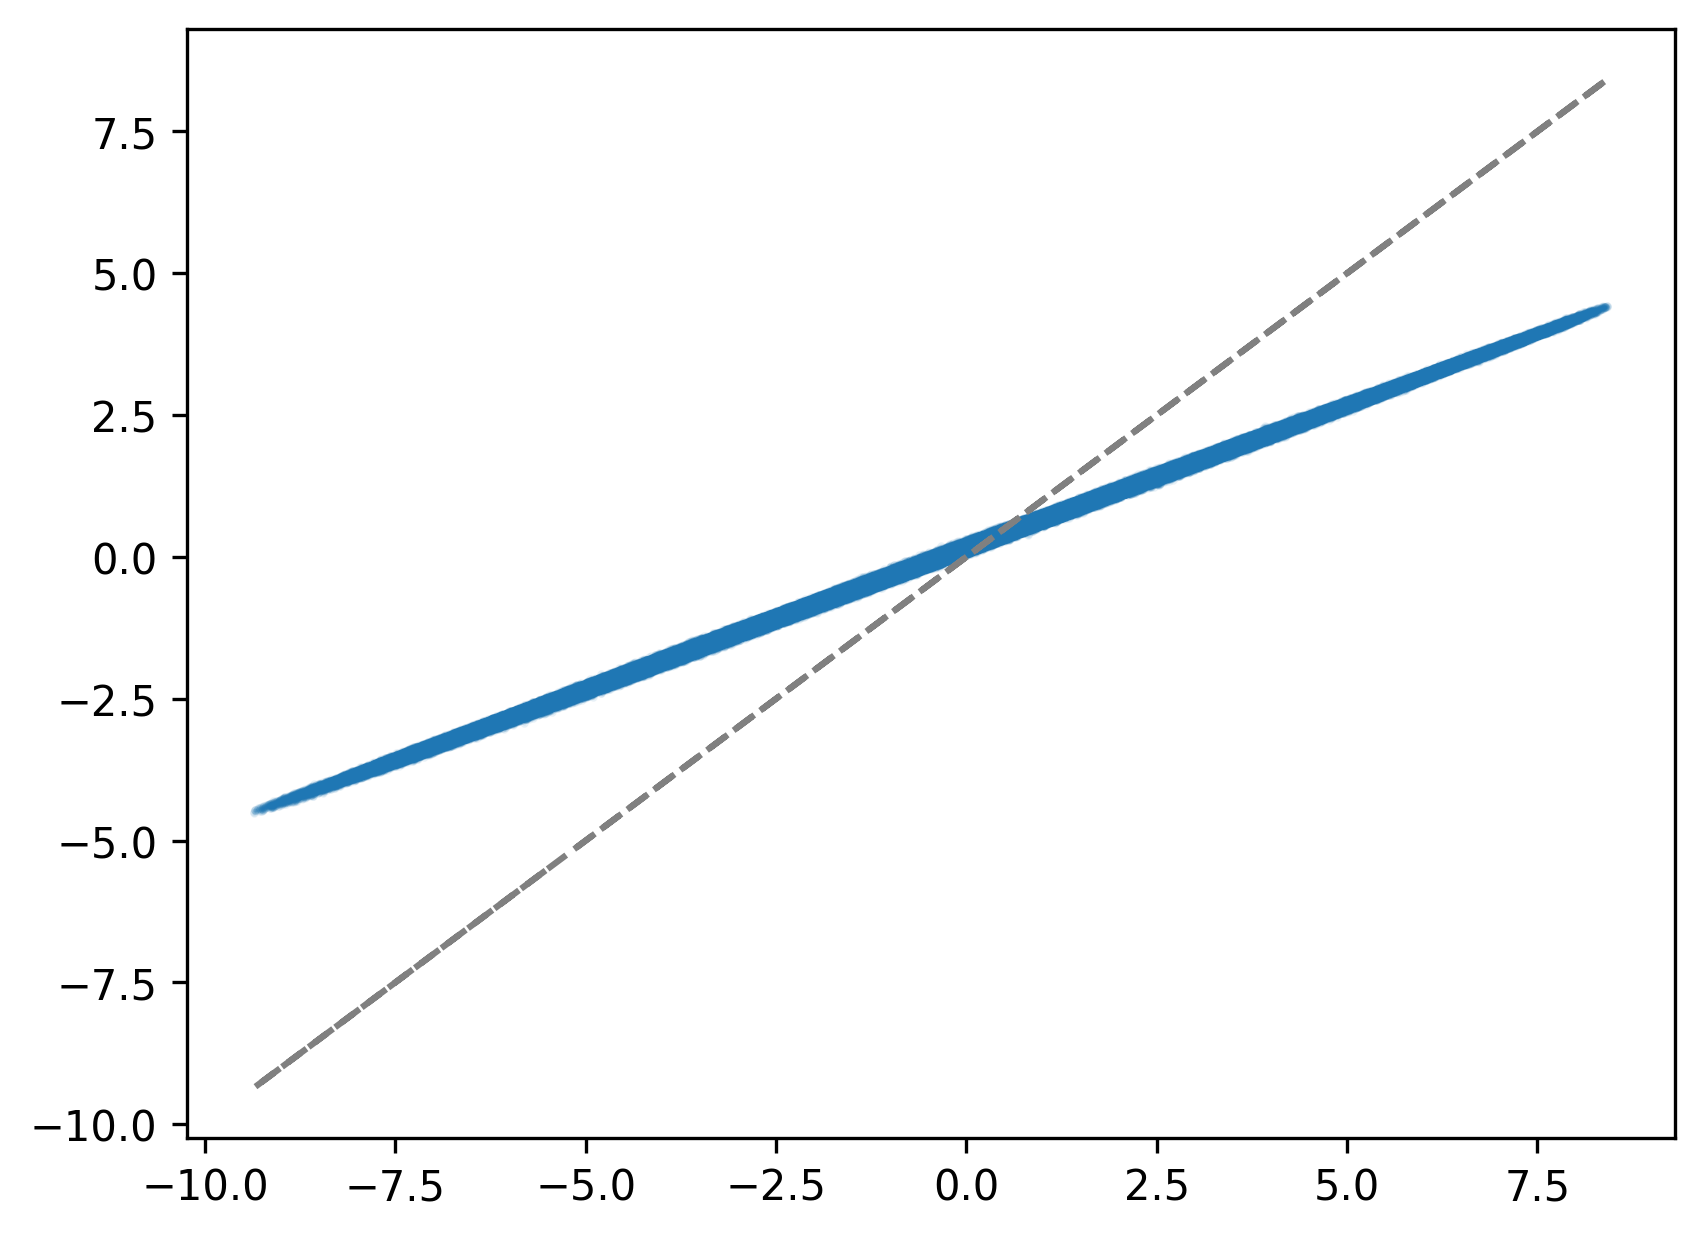

In [19]:
plt.scatter(
    pot_lr[0].flatten(),  # *norm,
    pot_hr[0].flatten(),
    marker="o",
    s=1,
    alpha=0.1,
)
plt.plot(
    pot_lr[0].flatten(),
    pot_lr[0].flatten(),
    linestyle="dashed",
    color="gray",
)

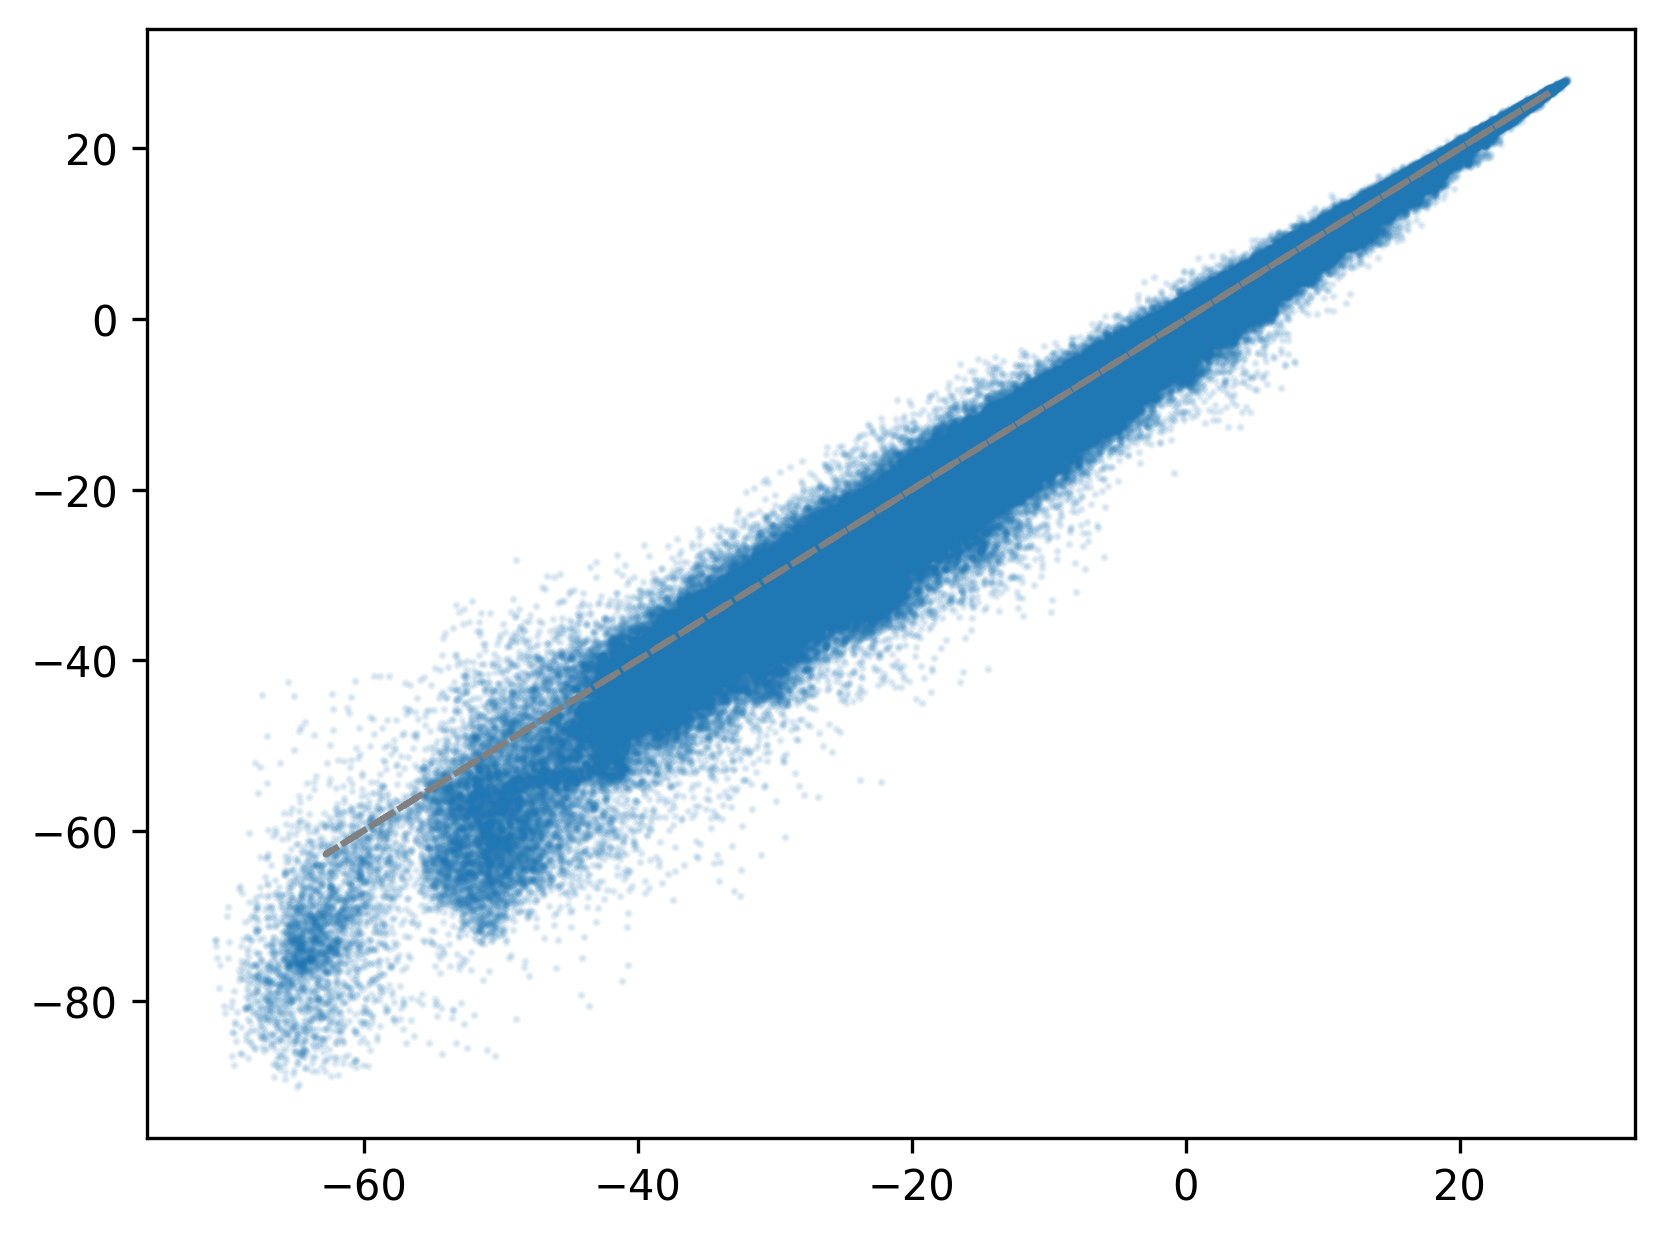

In [20]:
plt.scatter(
    pot_lr[-1].flatten() / 2,  # *norm,
    pot_hr[-1].flatten(),
    marker="o",
    s=1,
    alpha=0.1,
)
plt.plot(
    pot_lr[-2].flatten() / 2,
    pot_lr[-2].flatten() / 2,
    linestyle="dashed",
    color="gray",
)

Text(0.5, 1.0, 'HR')

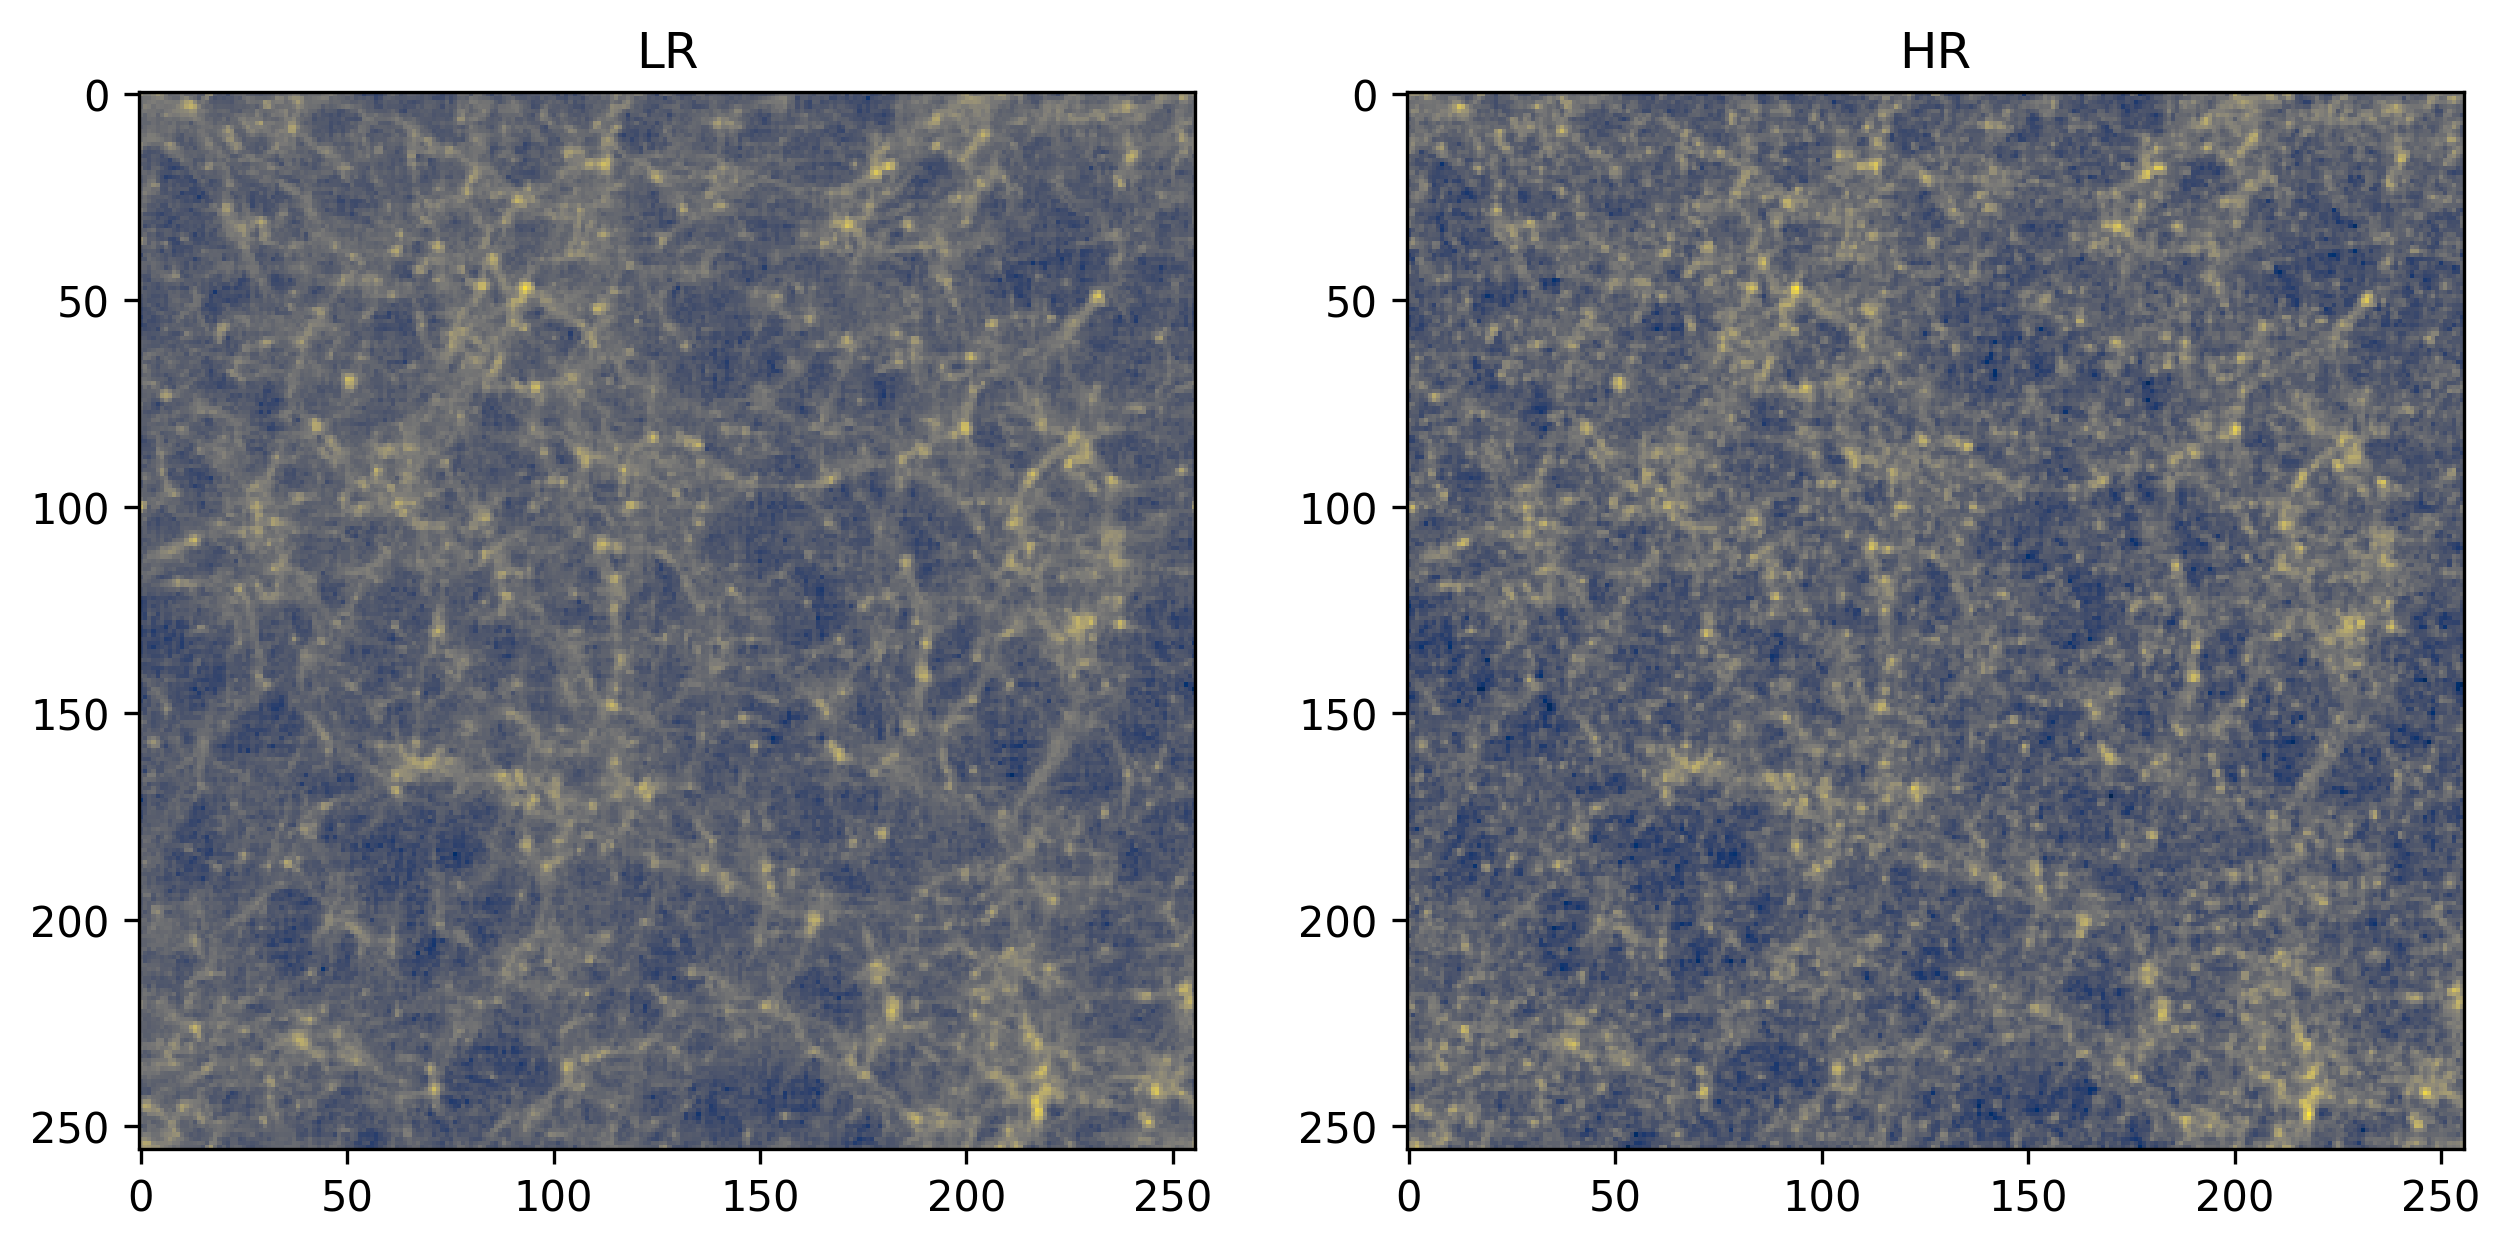

In [26]:
mesh_plot = 256
cmap = "cividis"

delta_hr = get_delta(pos_hr[-1] * mesh_plot, (mesh_plot, mesh_plot, mesh_plot))
norm = LogNorm(
    vmin=delta_hr.sum(axis=0).min(),
    vmax=delta_hr.sum(axis=0).max(),
)
delta_lr = get_delta(pos_lr[-1] * mesh_plot, (mesh_plot, mesh_plot, mesh_plot))


fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].imshow((delta_lr[:, :, :]).sum(axis=0), norm=norm, cmap=cmap)

ax[1].imshow((delta_hr[:, :, :]).sum(axis=0), norm=norm, cmap=cmap)

ax[0].set_title("LR")
ax[1].set_title("HR")

In [24]:
k, pk_lr = power_spectrum(
    compensate_cic(delta_lr),
    boxsize=np.array([256.0] * 3),
    kmin=np.pi / 256.0,
    dk=2 * np.pi / 256.0,
)

k, pk_hr = power_spectrum(
    compensate_cic(delta_hr),
    boxsize=np.array([256.0] * 3),
    kmin=np.pi / 256.0,
    dk=2 * np.pi / 256.0,
)

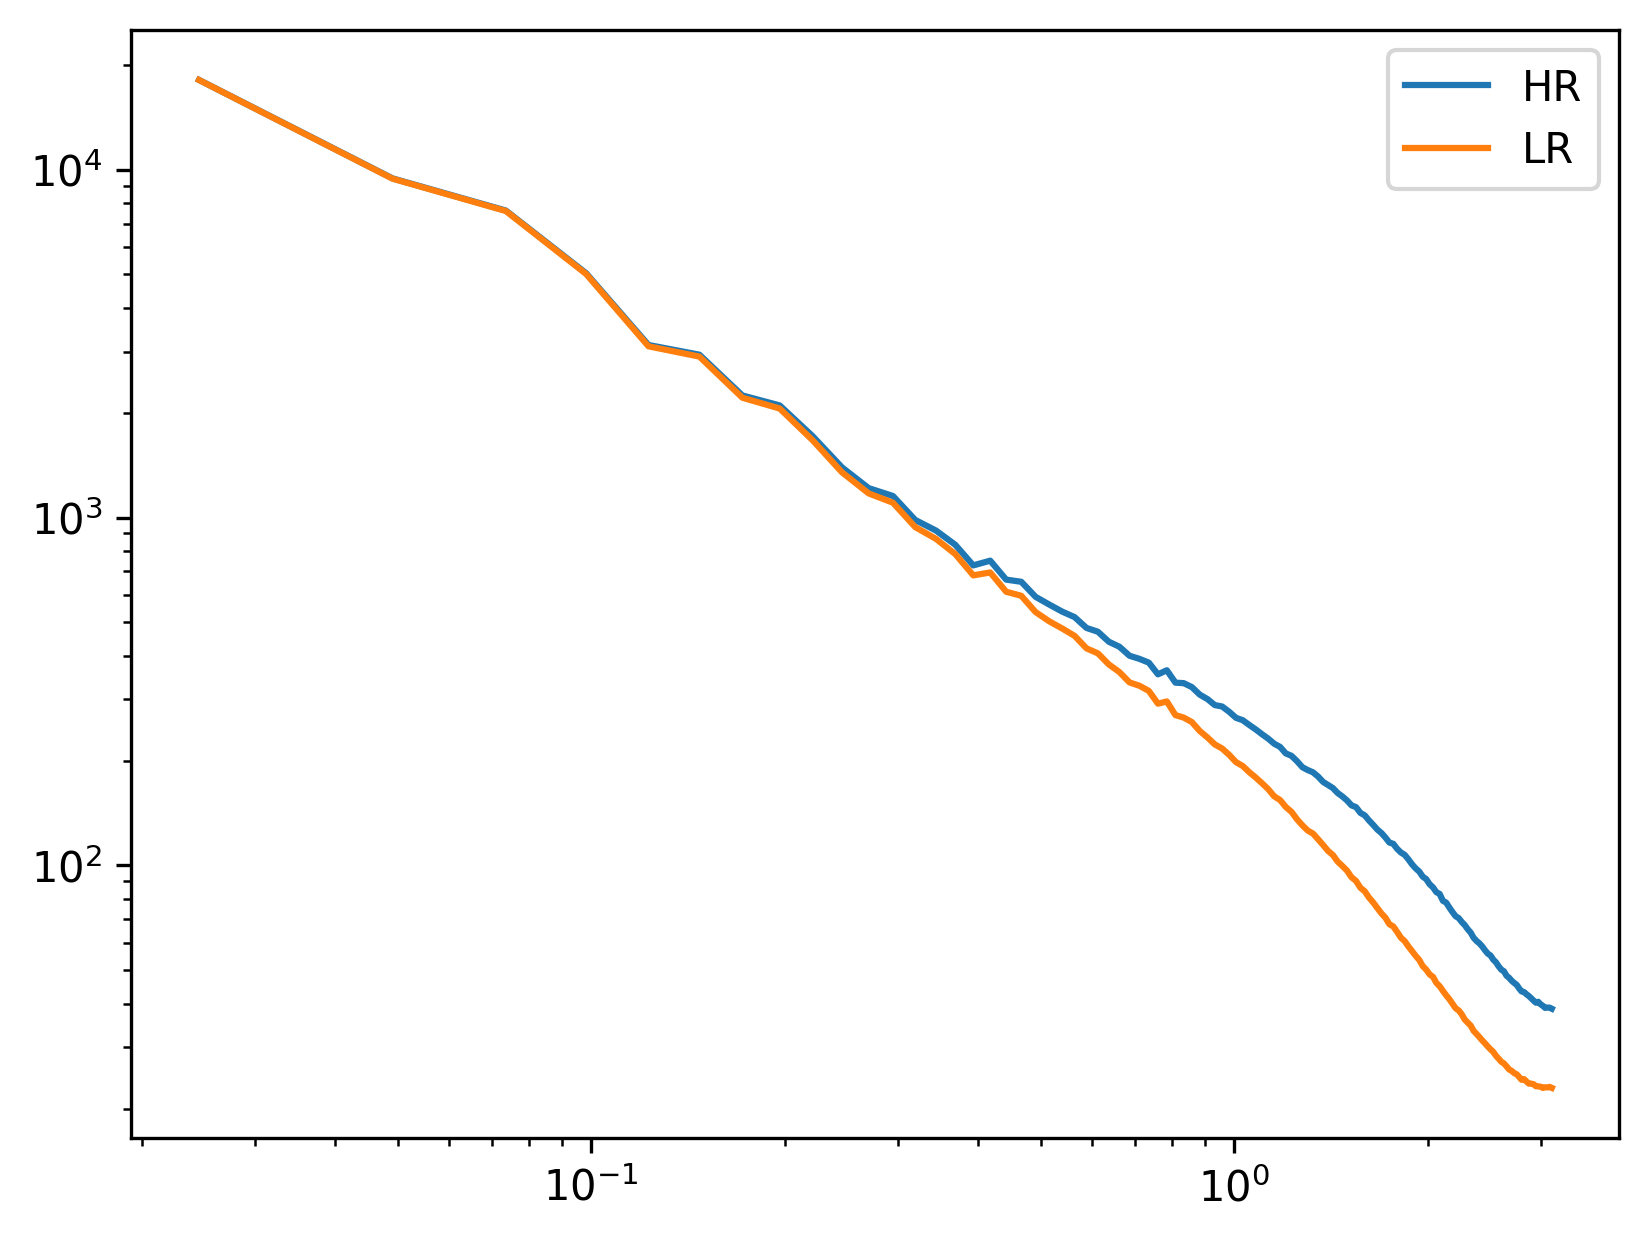

In [25]:
plt.loglog(k, pk_hr, label="HR")
plt.loglog(k, pk_lr, label="LR")
plt.legend()

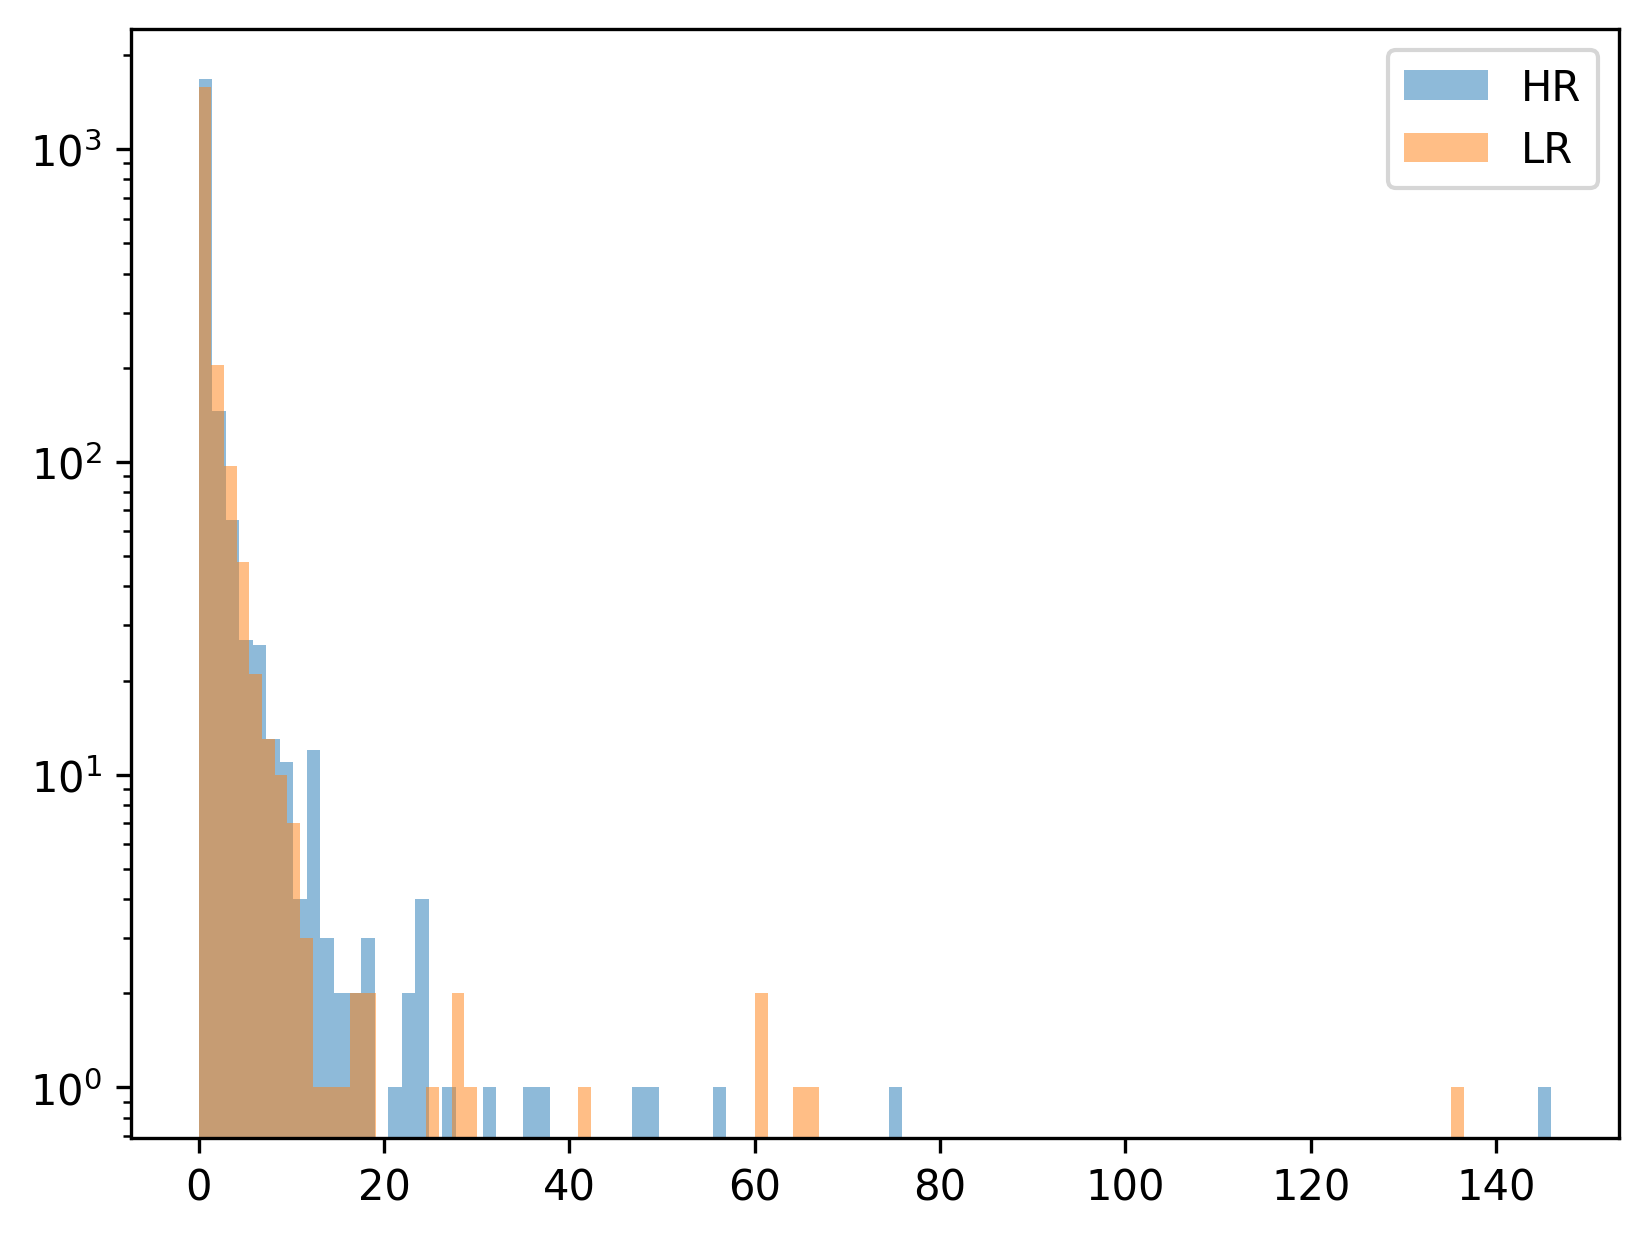

In [27]:
_ = plt.hist(delta_hr.flatten()[:2000], bins=100, alpha=0.5, label="HR", log=True)
_ = plt.hist(delta_lr.flatten()[:2000], bins=100, alpha=0.5, label="LR", log=True)
plt.legend()

## Check dataset as read by network

In [34]:
train_ds, val_ds, _ = load_datasets(
    1, 1, 0, mesh_hr=256, mesh_lr=128, data_dir=data_dir, box_size=box_size
)

In [35]:
hr_ds = train_ds[0]["hr"]
lr_ds = train_ds[0]["lr"]

Text(0.5, 1.0, 'HR')

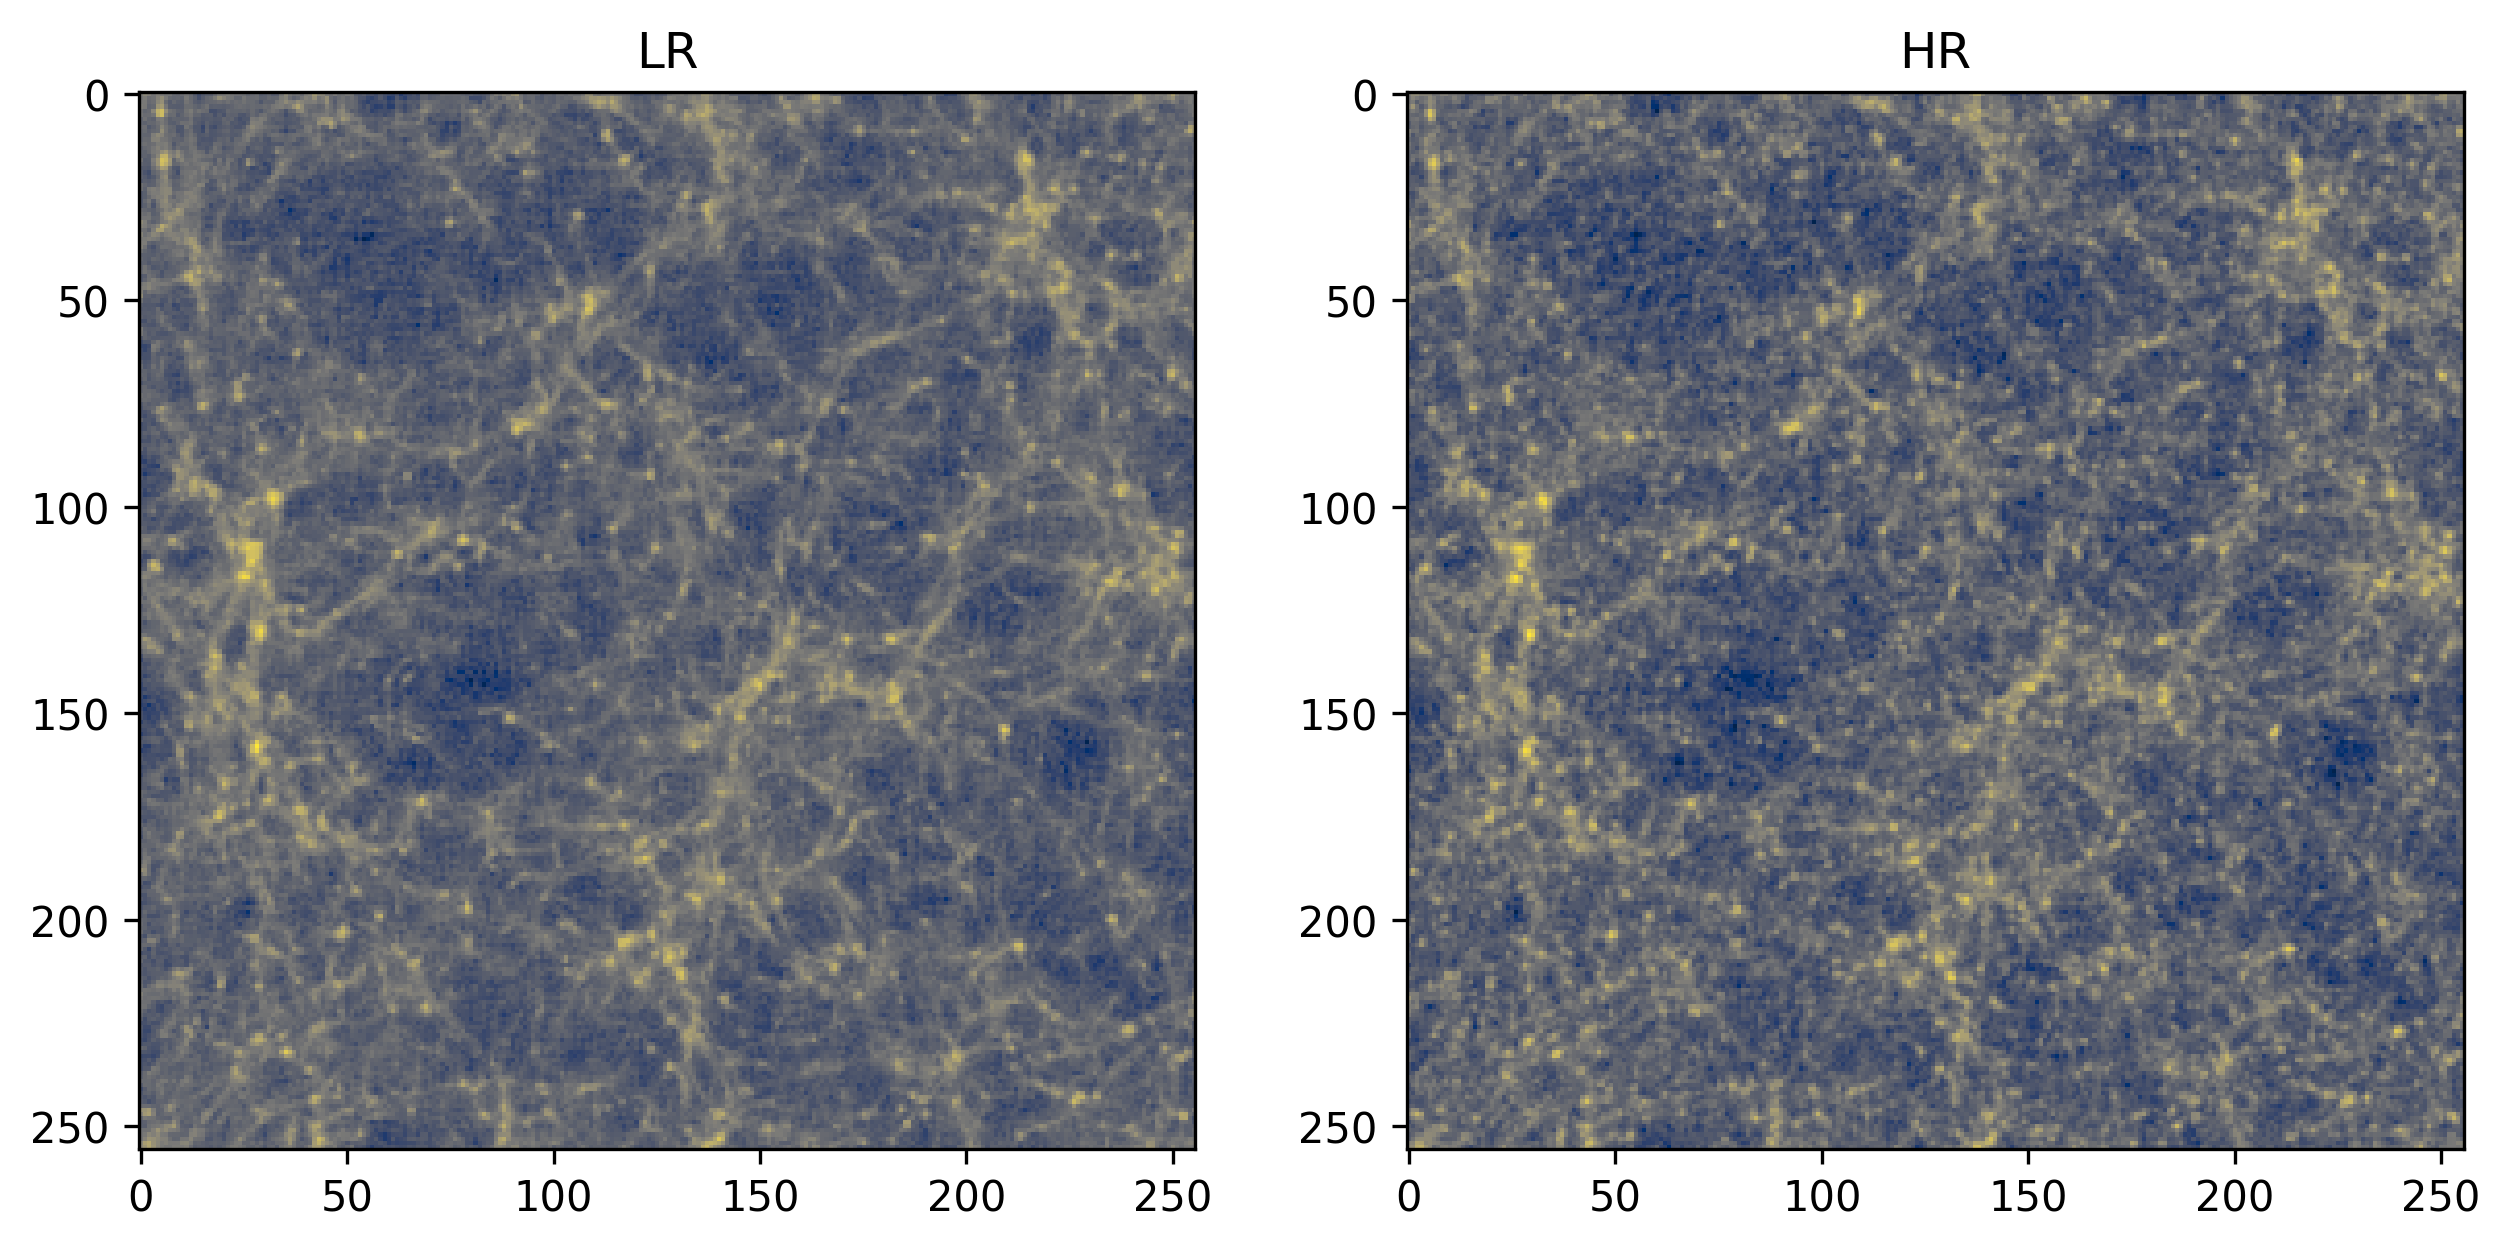

In [38]:
mesh_plot = 256
norm = LogNorm()  # (vmin=0, vmax=150)
cmap = "cividis"

delta_hr = get_delta(hr_ds.positions[-1] * mesh_plot, (mesh_plot, mesh_plot, mesh_plot))
delta_lr = get_delta(lr_ds.positions[-1] * mesh_plot, (mesh_plot, mesh_plot, mesh_plot))


fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].imshow((delta_lr[:, :, :]).sum(axis=0), norm=norm, cmap=cmap)

ax[1].imshow((delta_hr[:, :, :]).sum(axis=0), norm=norm, cmap=cmap)

ax[0].set_title("LR")
ax[1].set_title("HR")

Text(0, 0.5, 'LR Pot')

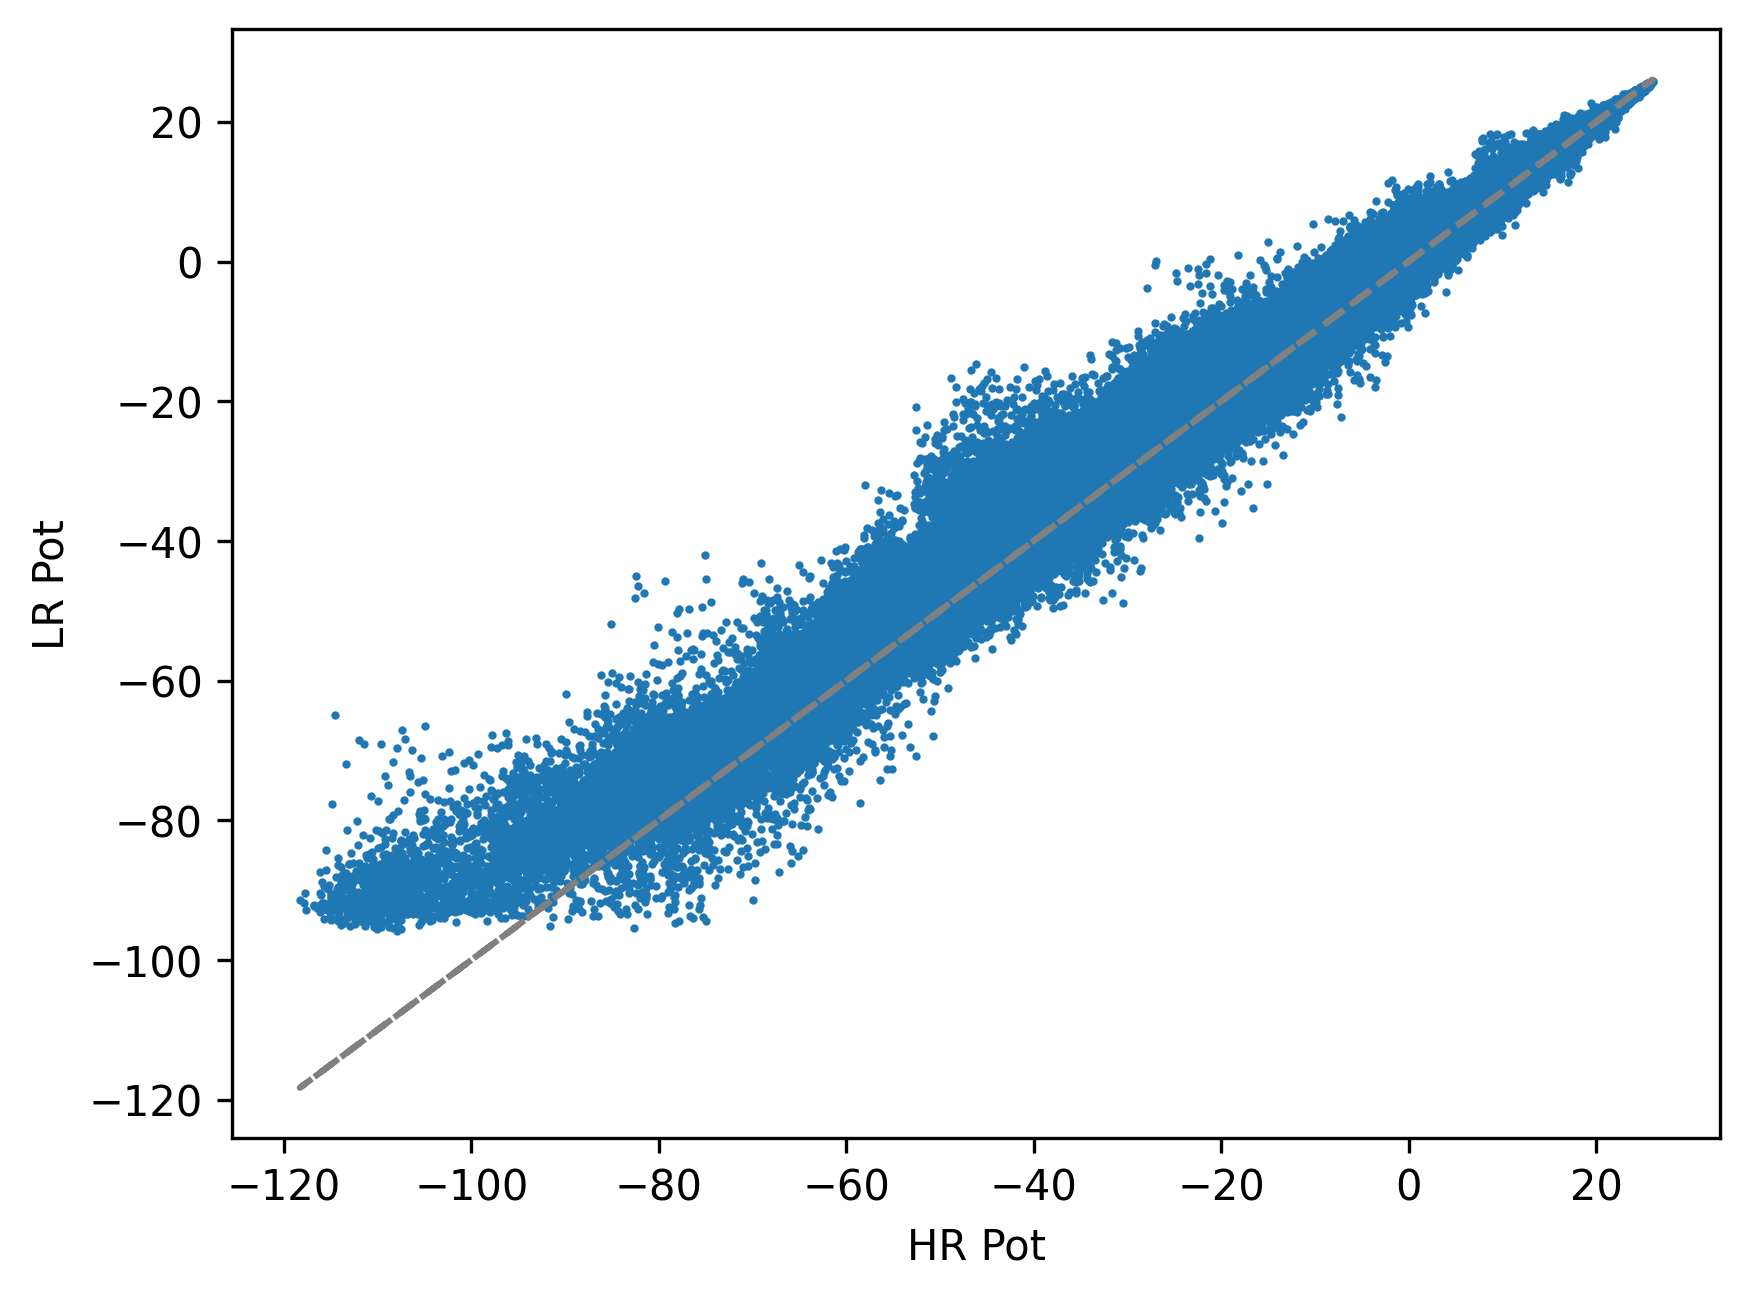

In [39]:
plt.scatter(
    hr_ds.potential[-1],
    lr_ds.potential[-1],
    marker="o",
    s=1,
)
plt.plot(hr_ds.potential[-1], hr_ds.potential[-1], linestyle="dashed", color="gray")
plt.xlabel("HR Pot")
plt.ylabel("LR Pot")

In [33]:
# Compare Pk (is downsampling doing something wrong?)

In [40]:
k, pk_lr = power_spectrum(
    compensate_cic(delta_lr),
    boxsize=np.array([256.0] * 3),
    kmin=np.pi / 256.0,
    dk=2 * np.pi / 256.0,
)

k, pk_hr = power_spectrum(
    compensate_cic(delta_hr),
    boxsize=np.array([256.0] * 3),
    kmin=np.pi / 256.0,
    dk=2 * np.pi / 256.0,
)

Text(0, 0.5, '$P(k)$')

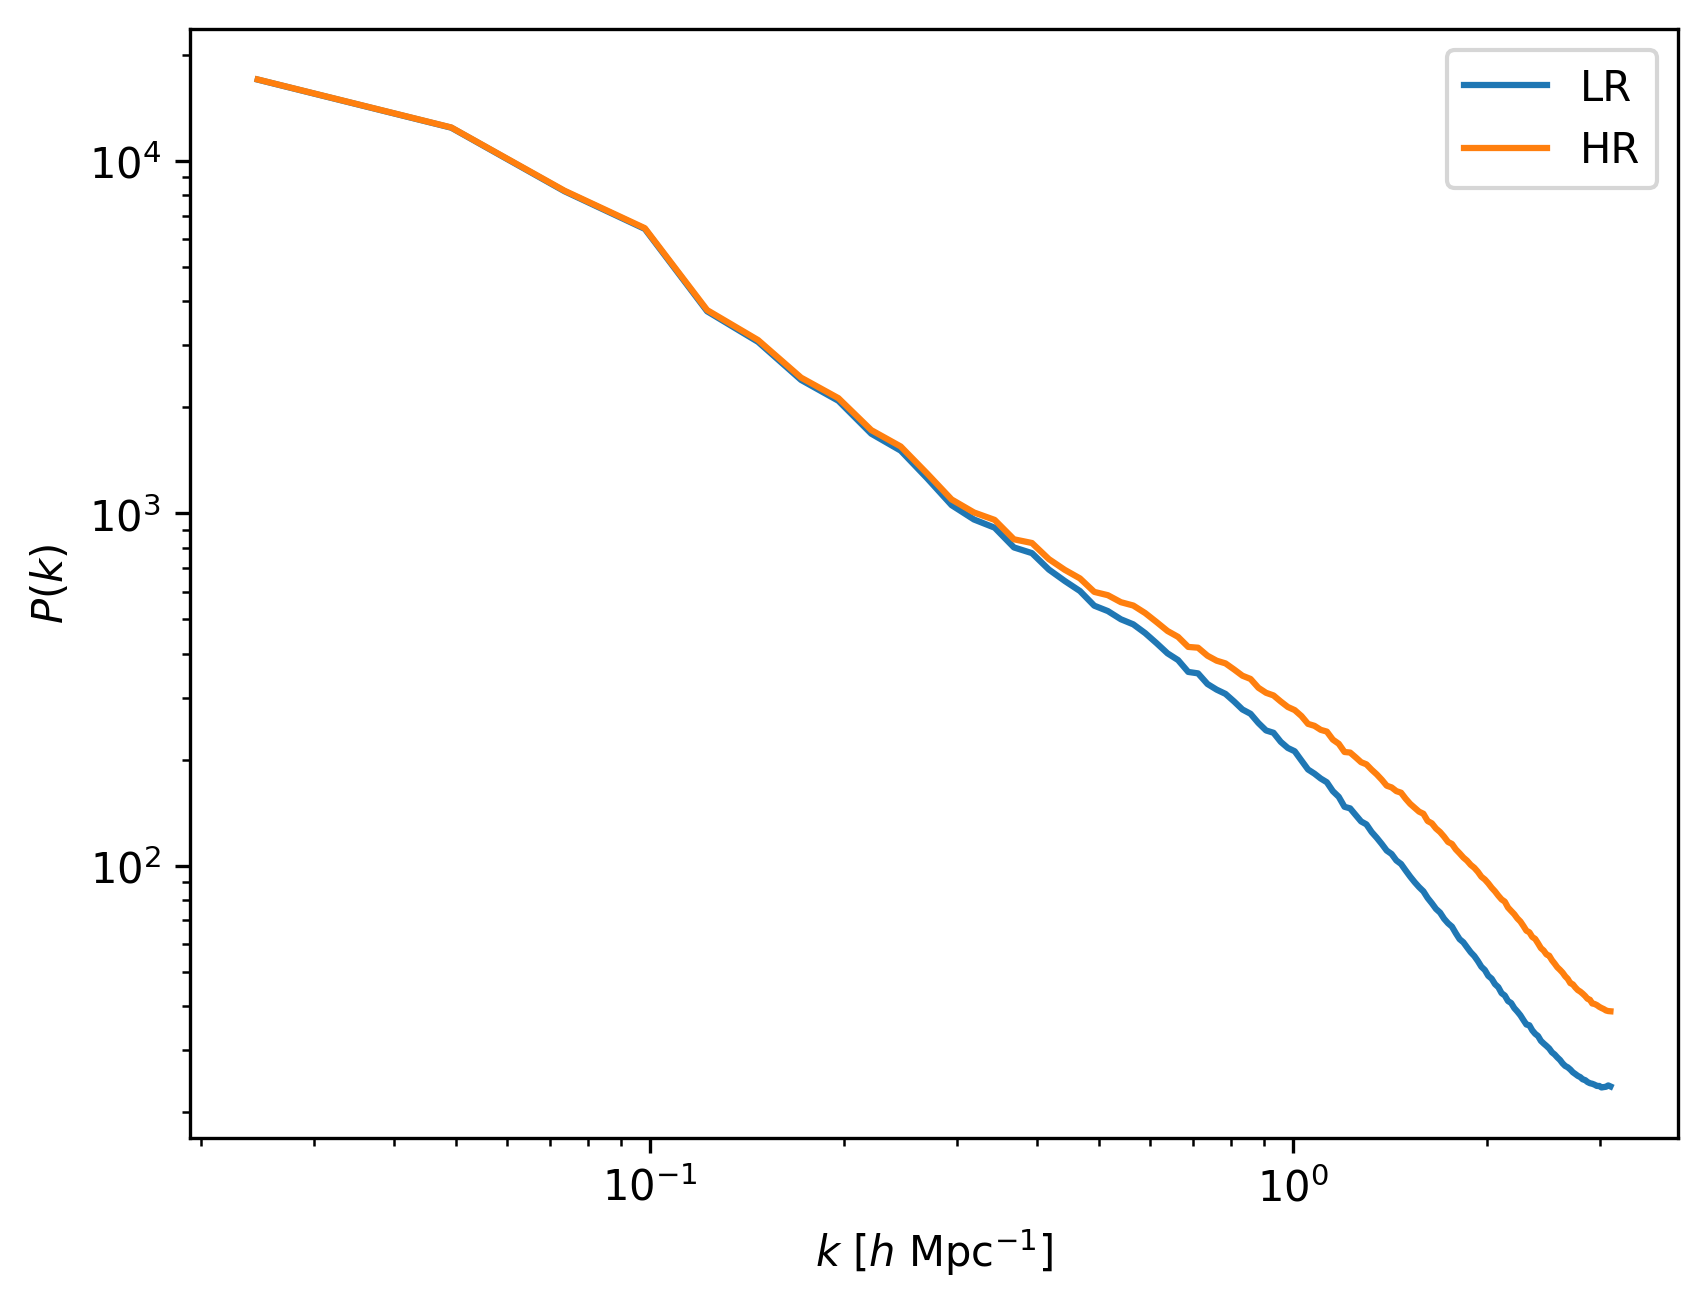

In [41]:
plt.loglog(k, pk_lr, label="LR")
plt.loglog(k, pk_hr, label="HR")
plt.legend()
plt.xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]")
plt.ylabel(r"$P(k)$")